# **Model CRNN menggunakan 15 segmentasi**


In [1]:
import json
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow.keras as keras
import matplotlib.pyplot as plt

In [2]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd

In [ ]:
DATA_PATH = "data_15_segmen.json"

In [4]:
def load_dataset(file_path):
    with open(file_path, "r") as file:
        dataset = json.load(file)
    
    features = np.array(dataset["mfcc"])
    labels = np.array(dataset["labels"])
    genre_mapping = dataset.get("mapping", {})
    
    return features, labels, genre_mapping

In [5]:
def split_dataset(train_ratio, val_ratio, test_ratio):
    X, y, genre_mapping = load_dataset(DATA_PATH)
    
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=(1 - train_ratio), random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(test_ratio / (val_ratio + test_ratio)), random_state=42)
    
    X_train = X_train[..., np.newaxis]
    X_val = X_val[..., np.newaxis]
    X_test = X_test[..., np.newaxis]
    
    return X_train, X_val, X_test, y_train, y_val, y_test, genre_mapping

In [6]:
def create_model(input_shape):
    model = keras.Sequential([
        keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'),
        keras.layers.BatchNormalization(),
        
        keras.layers.Conv2D(32, (3, 3), activation='relu'),
        keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'),
        keras.layers.BatchNormalization(),
        
        keras.layers.Conv2D(32, (2, 2), activation='relu'),
        keras.layers.MaxPooling2D((2, 2), strides=(2, 2), padding='same'),
        keras.layers.BatchNormalization(),
        
        keras.layers.Reshape((-1, 32)),
        
        keras.layers.LSTM(64, return_sequences=True),
        keras.layers.LSTM(64),
        
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.3),
        
        keras.layers.Dense(10, activation='softmax')
    ])
    
    return model

In [7]:
def plot_history(history, ratio):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    axes[0].plot(history.history["accuracy"], label="Akurasi Pelatihan")
    axes[0].plot(history.history["val_accuracy"], label="Akurasi Validasi")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].legend(loc="lower right")
    axes[0].set_title(f"Akurasi Model 10 Segmen - {ratio}")
    
    axes[1].plot(history.history["loss"], label="Loss Pelatihan")
    axes[1].plot(history.history["val_loss"], label="Loss Validasi")
    axes[1].set_ylabel("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend(loc="upper right")
    axes[1].set_title(f"Model Loss 10 Segmen - {ratio}")
    
    plt.tight_layout()
    plt.show()


def evaluate_performance(model, X_test, y_test, genre_mapping, ratio):
    test_predictions = model.predict(X_test)
    test_predicted_labels = np.argmax(test_predictions, axis=1)
    
    test_conf_matrix = confusion_matrix(y_test, test_predicted_labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=genre_mapping, yticklabels=genre_mapping)
    plt.title(f'Confusion Matrix 10 Segmen - {ratio}')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()
    
    report_dict = classification_report(y_test, test_predicted_labels, target_names=genre_mapping, output_dict=True)
    report_df = pd.DataFrame(report_dict).transpose()
    report_df = report_df.mul(100).round(2)
    
    plt.figure(figsize=(6, 10))
    sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap="Blues", fmt=".2f")
    plt.title(f"Classification Report 10 Segmen - {ratio}")
    plt.xlabel("Metrics")
    plt.ylabel("Class")
    plt.show()



Evaluating for Train 60.0%, Val 20.0%, Test 20.0%...



c:\Users\Arma Rizki\OneDrive - UGM 365\Documents\TUGAS AKHIR\skripsi\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 85, 11, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 43, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 43, 6, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 41, 4, 32)      │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 21, 2, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 2, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 1, 32)      │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 1, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,746 (299.79 KB)

 Trainable params: 76,554 (299.04 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.2886 - loss: 2.0502 - val_accuracy: 0.5229 - val_loss: 1.4011
Epoch 2/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5027 - loss: 1.3888 - val_accuracy: 0.6047 - val_loss: 1.1656
Epoch 3/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5710 - loss: 1.2342 - val_accuracy: 0.6304 - val_loss: 1.0642
Epoch 4/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.6173 - loss: 1.1199 - val_accuracy: 0.6495 - val_loss: 1.0147
Epoch 5/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.6443 - loss: 1.0386 - val_accuracy: 0.6450 - val_loss: 0.9959
Epoch 6/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.6725 - loss: 0.9675 - val_accuracy: 0.6863 - val_loss: 0.9181
Epoch 7/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.6932 - loss: 0.9223 - val_accuracy: 0.7139 - val_loss: 0.8252
Epoch 8/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.7068 - loss: 0.8850 - 

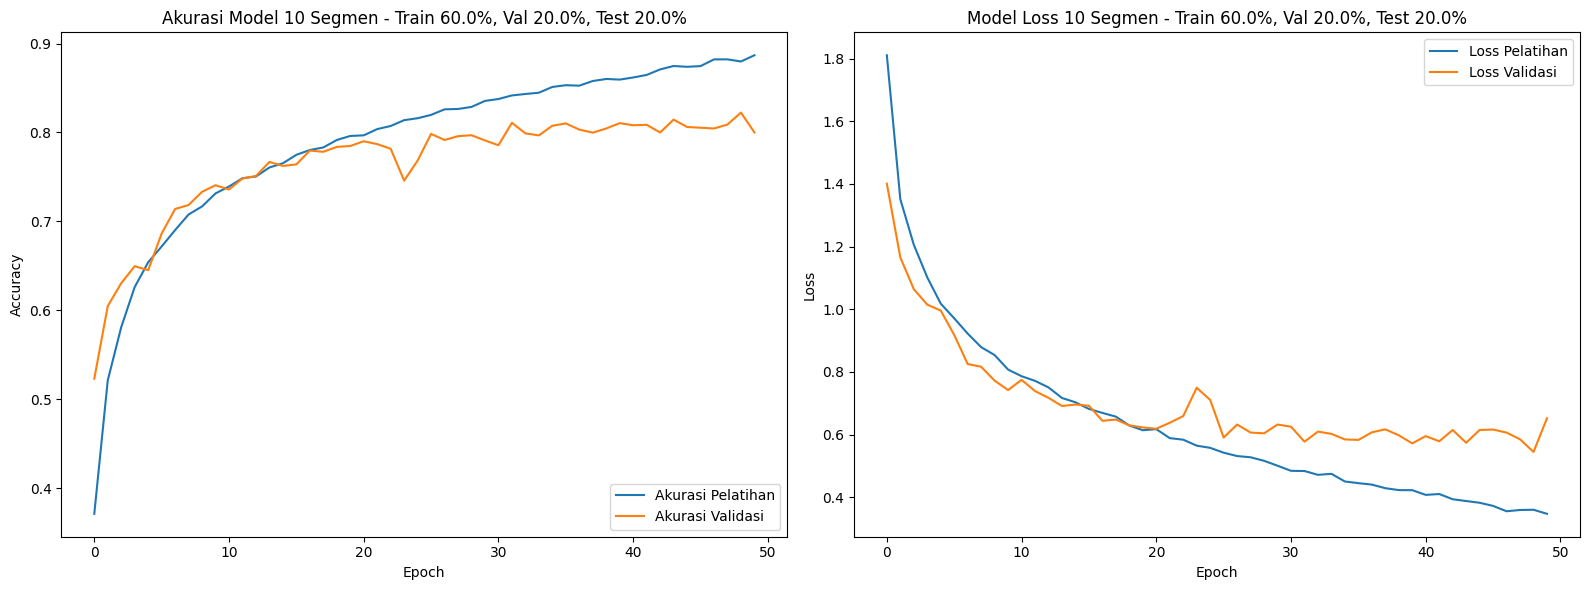

182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


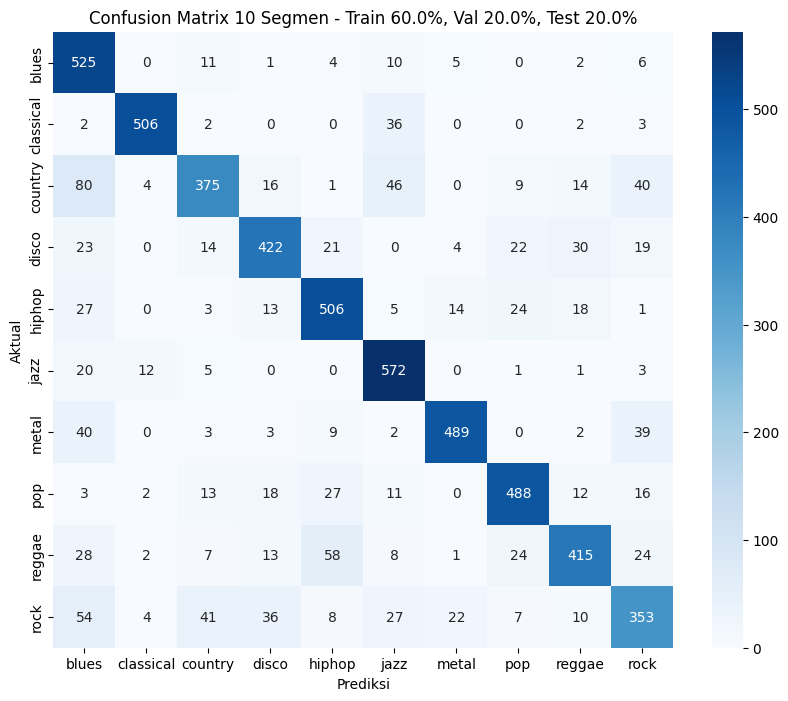

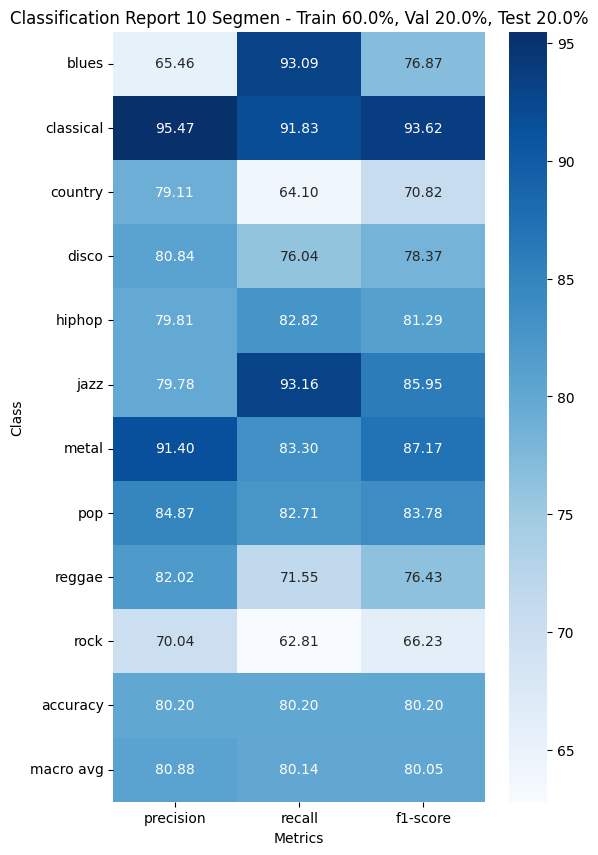


Evaluating for Train 70.0%, Val 15.0%, Test 15.0%...



c:\Users\Arma Rizki\OneDrive - UGM 365\Documents\TUGAS AKHIR\skripsi\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 85, 11, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 43, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 43, 6, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 41, 4, 32)      │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 21, 2, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 21, 2, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 20, 1, 32)      │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 10, 1, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 10, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,746 (299.79 KB)

 Trainable params: 76,554 (299.04 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.3069 - loss: 2.0158 - val_accuracy: 0.5102 - val_loss: 1.4080
Epoch 2/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.5149 - loss: 1.3750 - val_accuracy: 0.5948 - val_loss: 1.1468
Epoch 3/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.5768 - loss: 1.2175 - val_accuracy: 0.6257 - val_loss: 1.0572
Epoch 4/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6238 - loss: 1.1063 - val_accuracy: 0.6634 - val_loss: 0.9734
Epoch 5/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6502 - loss: 1.0452 - val_accuracy: 0.6894 - val_loss: 0.9149
Epoch 6/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6682 - loss: 0.9674 - val_accuracy: 0.7048 - val_loss: 0.8537
Epoch 7/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6918 - loss: 0.9213 - val_accuracy: 0.7043 - val_loss: 0.8407
Epoch 8/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7016 - loss: 0.8978 - 

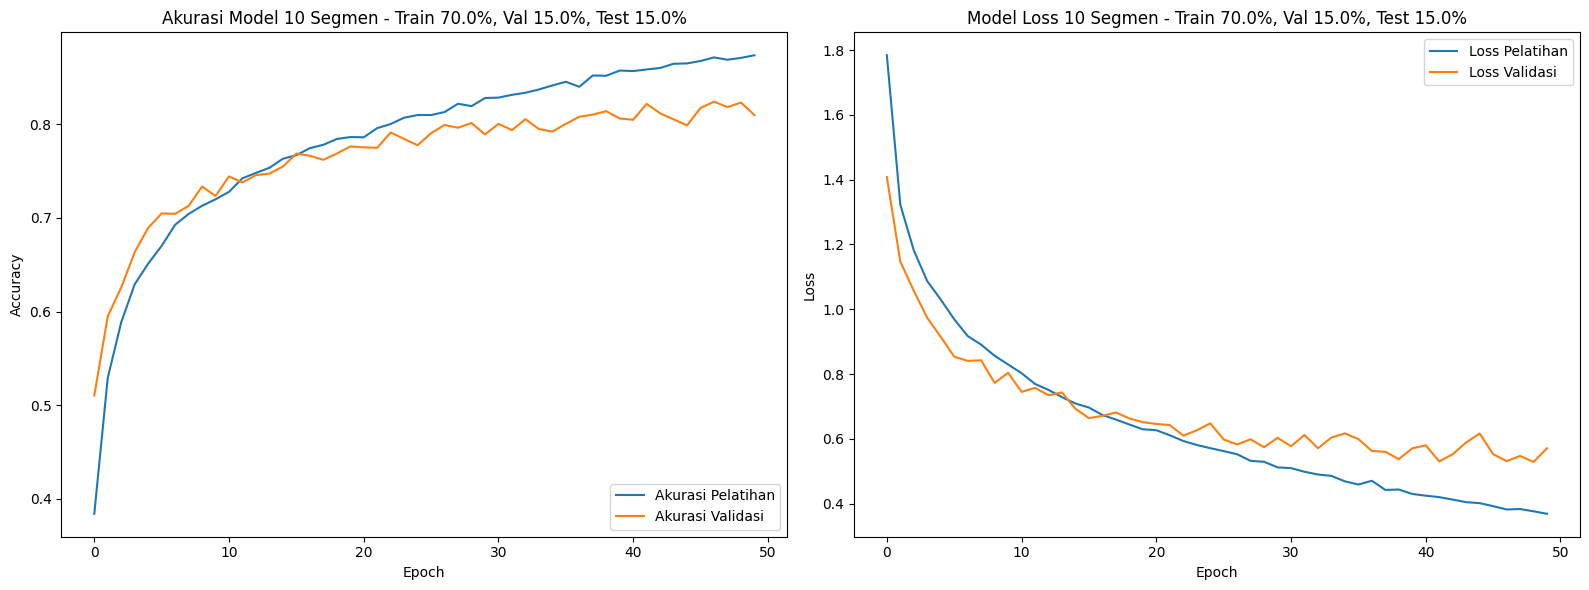

136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


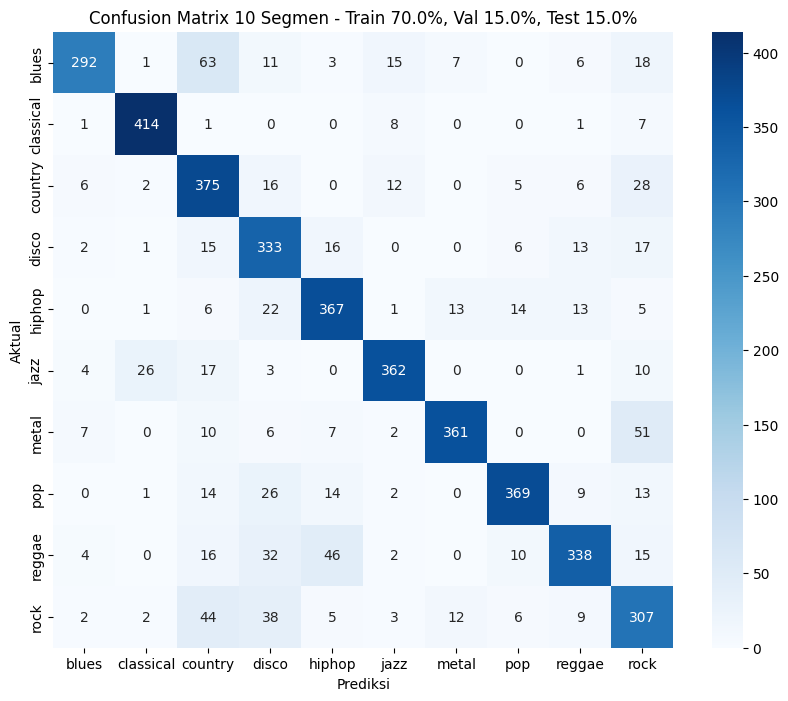

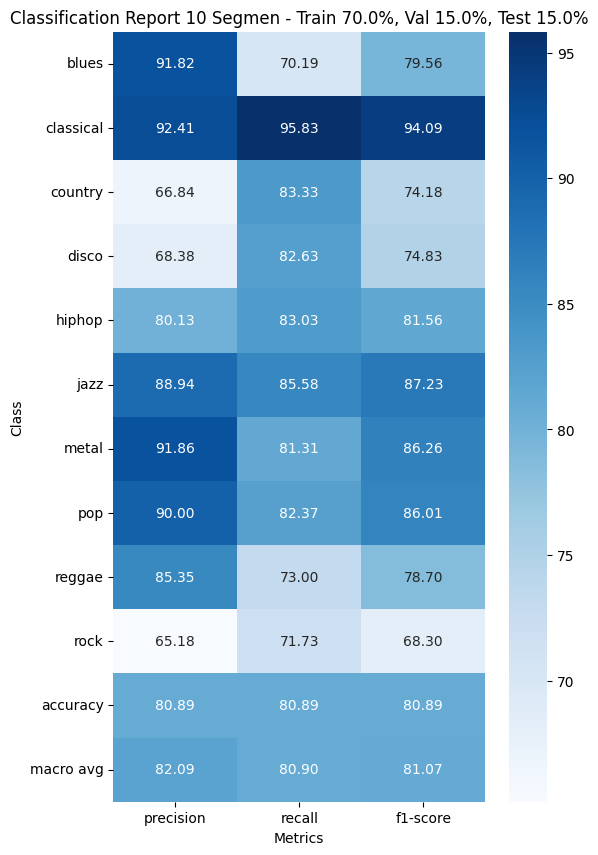


Evaluating for Train 80.0%, Val 10.0%, Test 10.0%...



c:\Users\Arma Rizki\OneDrive - UGM 365\Documents\TUGAS AKHIR\skripsi\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 85, 11, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 43, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 43, 6, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 41, 4, 32)      │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 21, 2, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 21, 2, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 20, 1, 32)      │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 10, 1, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 10, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,746 (299.79 KB)

 Trainable params: 76,554 (299.04 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/50
725/725 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.3252 - loss: 1.9779 - val_accuracy: 0.5474 - val_loss: 1.2827
Epoch 2/50
725/725 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.5349 - loss: 1.3209 - val_accuracy: 0.6126 - val_loss: 1.0921
Epoch 3/50
725/725 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.6035 - loss: 1.1477 - val_accuracy: 0.6419 - val_loss: 0.9961
Epoch 4/50
725/725 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.6380 - loss: 1.0558 - val_accuracy: 0.6699 - val_loss: 0.9197
Epoch 5/50
725/725 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.6632 - loss: 0.9894 - val_accuracy: 0.6864 - val_loss: 0.8832
Epoch 6/50
725/725 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.6831 - loss: 0.9400 - val_accuracy: 0.6951 - val_loss: 0.8642
Epoch 7/50
725/725 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.6985 - loss: 0.8881 - val_accuracy: 0.7144 - val_loss: 0.8113
Epoch 8/50
725/725 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.7175 - loss: 0.8444 - 

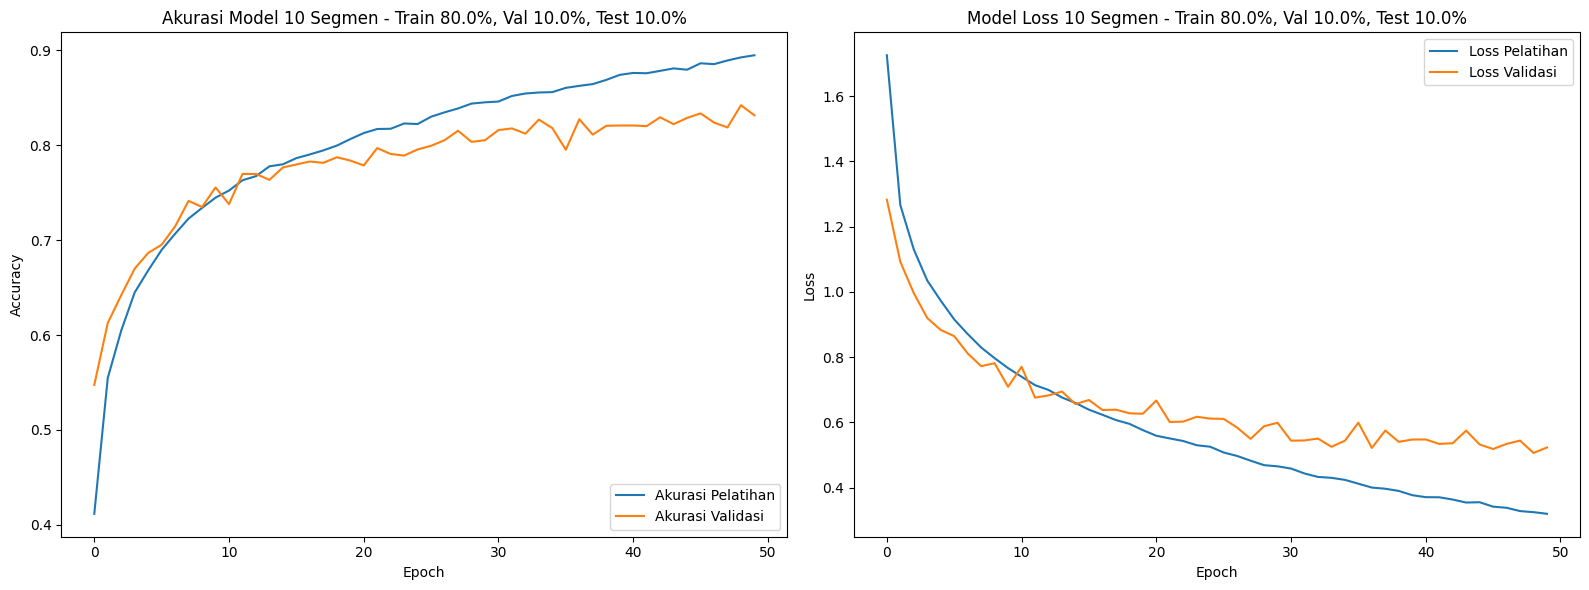

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


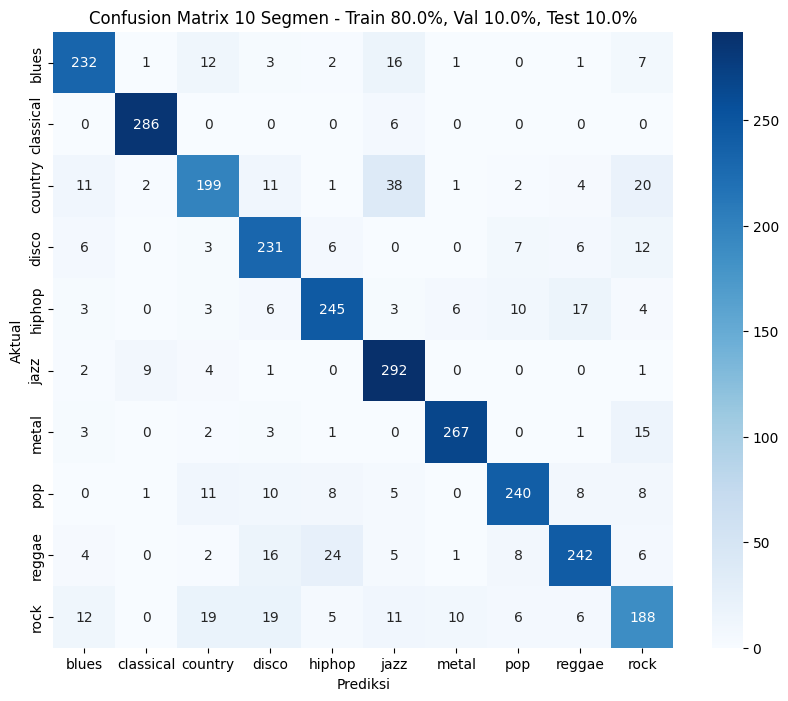

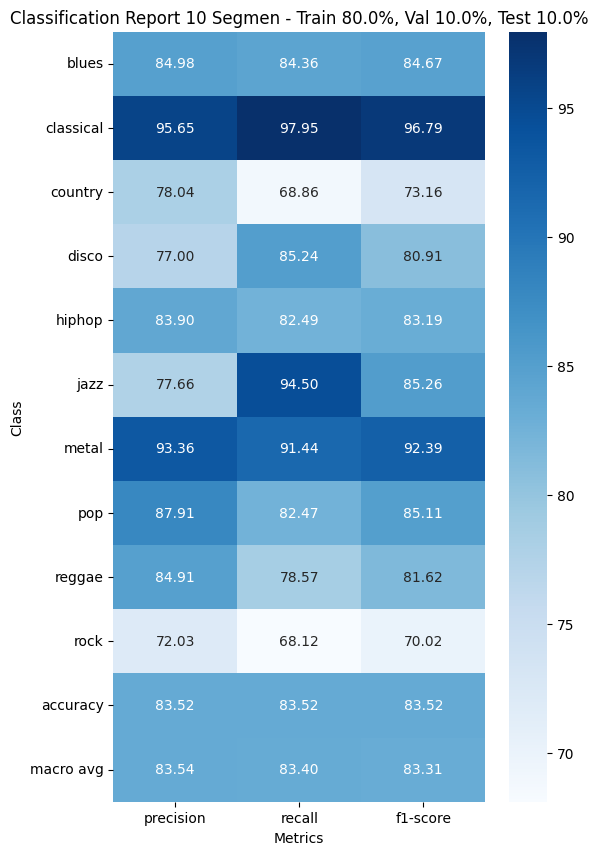

In [8]:
if __name__ == "__main__":
    split_ratios = [
        (0.6, 0.2, 0.2),
        (0.7, 0.15, 0.15),
        (0.8, 0.1, 0.1)
    ]
    
    for train_ratio, val_ratio, test_ratio in split_ratios:
        ratio_str = f"Train {train_ratio * 100}%, Val {val_ratio * 100}%, Test {test_ratio * 100}%"
        print(f"\nEvaluating for {ratio_str}...\n")
        
        X_train, X_val, X_test, y_train, y_val, y_test, genre_mapping = split_dataset(train_ratio, val_ratio, test_ratio)
        input_dim = (X_train.shape[1], X_train.shape[2], 1)
        
        model = create_model(input_dim)
        optimizer = keras.optimizers.Adam(learning_rate=0.0001)
        model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        
        model.summary()
        history = model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=32, epochs=50)
        plot_history(history, ratio_str)
        evaluate_performance(model, X_test, y_test, genre_mapping, ratio_str)